# Spam Detection: Naive Bayes vs k-NN vs SVM

**Student Name:** Mateo Tomaszeuski
**Date:** February 19, 2026

In this project, you'll:
1. Load a spam email dataset
2. Train a Naive Bayes classifier
3. Train a k-Nearest Neighbors classifier
4. Train an SVM classifier
5. Compare the results

<small><i>Note</i>: This project was created with the assistance of AI</small>

---

## Step 1: Import Libraries and Load Data

In [181]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [182]:
df = pd.read_csv('../data/spam_data.csv')

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['is_spam'].value_counts())
print("\nFirst few rows:")
df.head()

Dataset shape: (1000, 11)

Class distribution:
is_spam
0    600
1    400
Name: count, dtype: int64

First few rows:


,word_free,word_money,word_winner,word_click,word_urgent,num_exclamation,num_dollar,num_capitals,email_length,has_link,is_spam
0,0.116603,0.081405,0.248621,0.107026,0.084280,0.162809,0.042277,0.240659,101.836546,0.296066,0
1,0.150017,0.202468,0.071720,0.227412,0.228002,0.093779,0.123205,0.062907,90.571442,0.193681,0
2,0.009429,0.190923,0.094307,0.152571,0.272270,0.074788,0.123115,0.226665,130.369345,0.023094,0
3,0.085727,0.129830,0.205633,0.099737,0.016976,0.112176,0.283335,0.192520,98.526674,0.189685,0
4,0.050113,0.050286,0.011001,0.220921,0.199141,0.142389,0.253251,0.241701,96.637459,0.260481,0


## Step 2: Preprocessing the Data
* Clean the data
* Split the data into training and test sets.
* Feature Scaling

In [183]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
word_free          0
word_money         0
word_winner        0
word_click         0
word_urgent        0
num_exclamation    0
num_dollar         0
num_capitals       0
email_length       0
has_link           0
is_spam            0
dtype: int64


In [184]:
X = df.drop('is_spam', axis=1)
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Step 3: Train Naive Bayes Classifier

In [185]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

Naive Bayes Accuracy: 1.0000 (100.00%)


Confusion matrix and classification report.

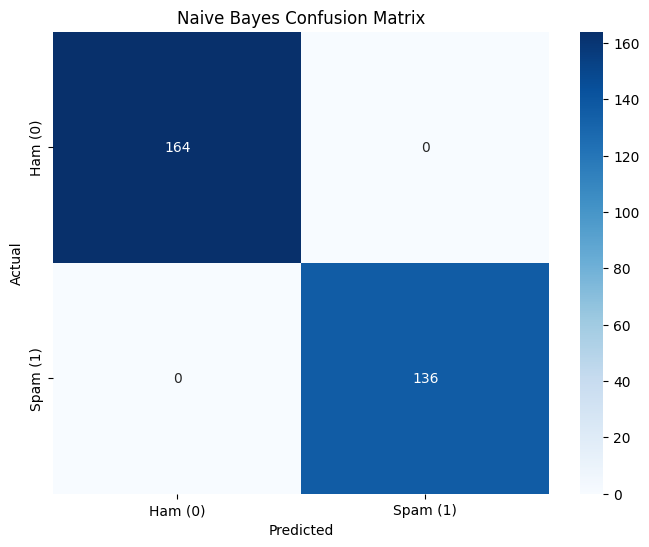


Naive Bayes Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       164
        Spam       1.00      1.00      1.00       136

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [186]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('Naive Bayes Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

## Step 4: Train k-Nearest Neighbors Classifier

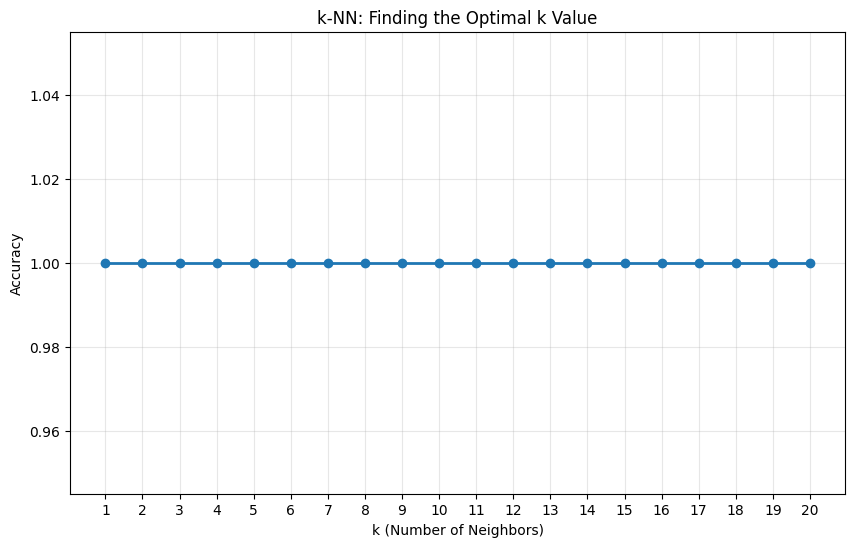


Best k value: 1
Best accuracy: 1.0000 (100.00%)


In [187]:
k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    score = knn_temp.score(X_test_scaled, y_test)
    k_scores.append(score)


plt.figure(figsize=(10, 6))
plt.plot(k_values, k_scores, marker='o', linestyle='-', linewidth=2)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('k-NN: Finding the Optimal k Value')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()


best_k = k_values[k_scores.index(max(k_scores))]
print(f"\nBest k value: {best_k}")
print(f"Best accuracy: {max(k_scores):.4f} ({max(k_scores)*100:.2f}%)")

In [188]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"k-NN Accuracy (k={best_k}): {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")

k-NN Accuracy (k=1): 1.0000 (100.00%)


Display your confusion matrix and classification report.

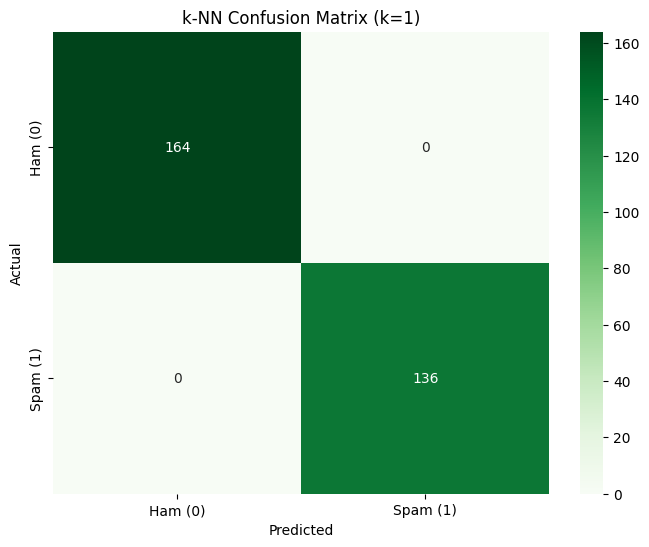


k-NN Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       164
        Spam       1.00      1.00      1.00       136

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [189]:
cm_knn = confusion_matrix(y_test, y_pred_knn)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.title(f'k-NN Confusion Matrix (k={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nk-NN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Ham', 'Spam']))

## Step 5: Train SVM Classifier

In [190]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

SVM Accuracy: 1.0000 (100.00%)


Display your confusion matrix and your classification report.

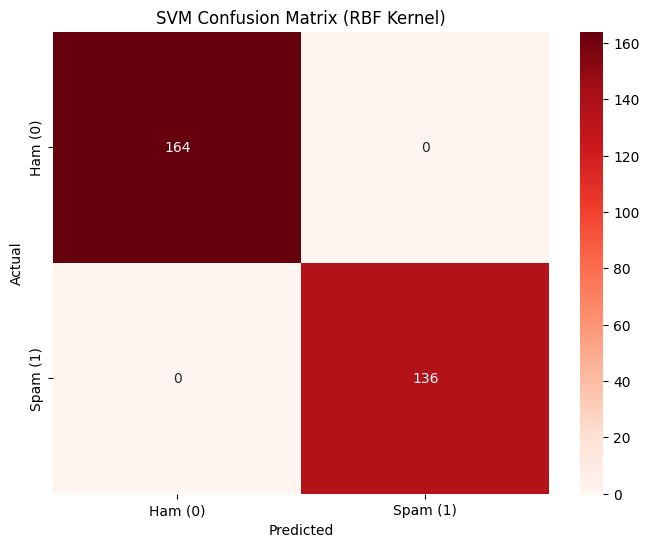


SVM Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       164
        Spam       1.00      1.00      1.00       136

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [191]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('SVM Confusion Matrix (RBF Kernel)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']))

## Step 6: Compare the Models
* Create graphs that compare model results
* Make calculations to compare model results

In [192]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = ['Naive Bayes', 'k-NN', 'SVM']
predictions = [y_pred_nb, y_pred_knn, y_pred_svm]

metrics_data = {
    'Model': models,
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for pred in predictions:
    metrics_data['Accuracy'].append(accuracy_score(y_test, pred))
    metrics_data['Precision'].append(precision_score(y_test, pred))
    metrics_data['Recall'].append(recall_score(y_test, pred))
    metrics_data['F1-Score'].append(f1_score(y_test, pred))

comparison_df = pd.DataFrame(metrics_data)
comparison_df = comparison_df.round(4)
print("Model Comparison Table:")
print(comparison_df)

Model Comparison Table:


         Model  Accuracy  Precision  Recall  F1-Score
0  Naive Bayes       1.0        1.0     1.0       1.0
1         k-NN       1.0        1.0     1.0       1.0
2          SVM       1.0        1.0     1.0       1.0


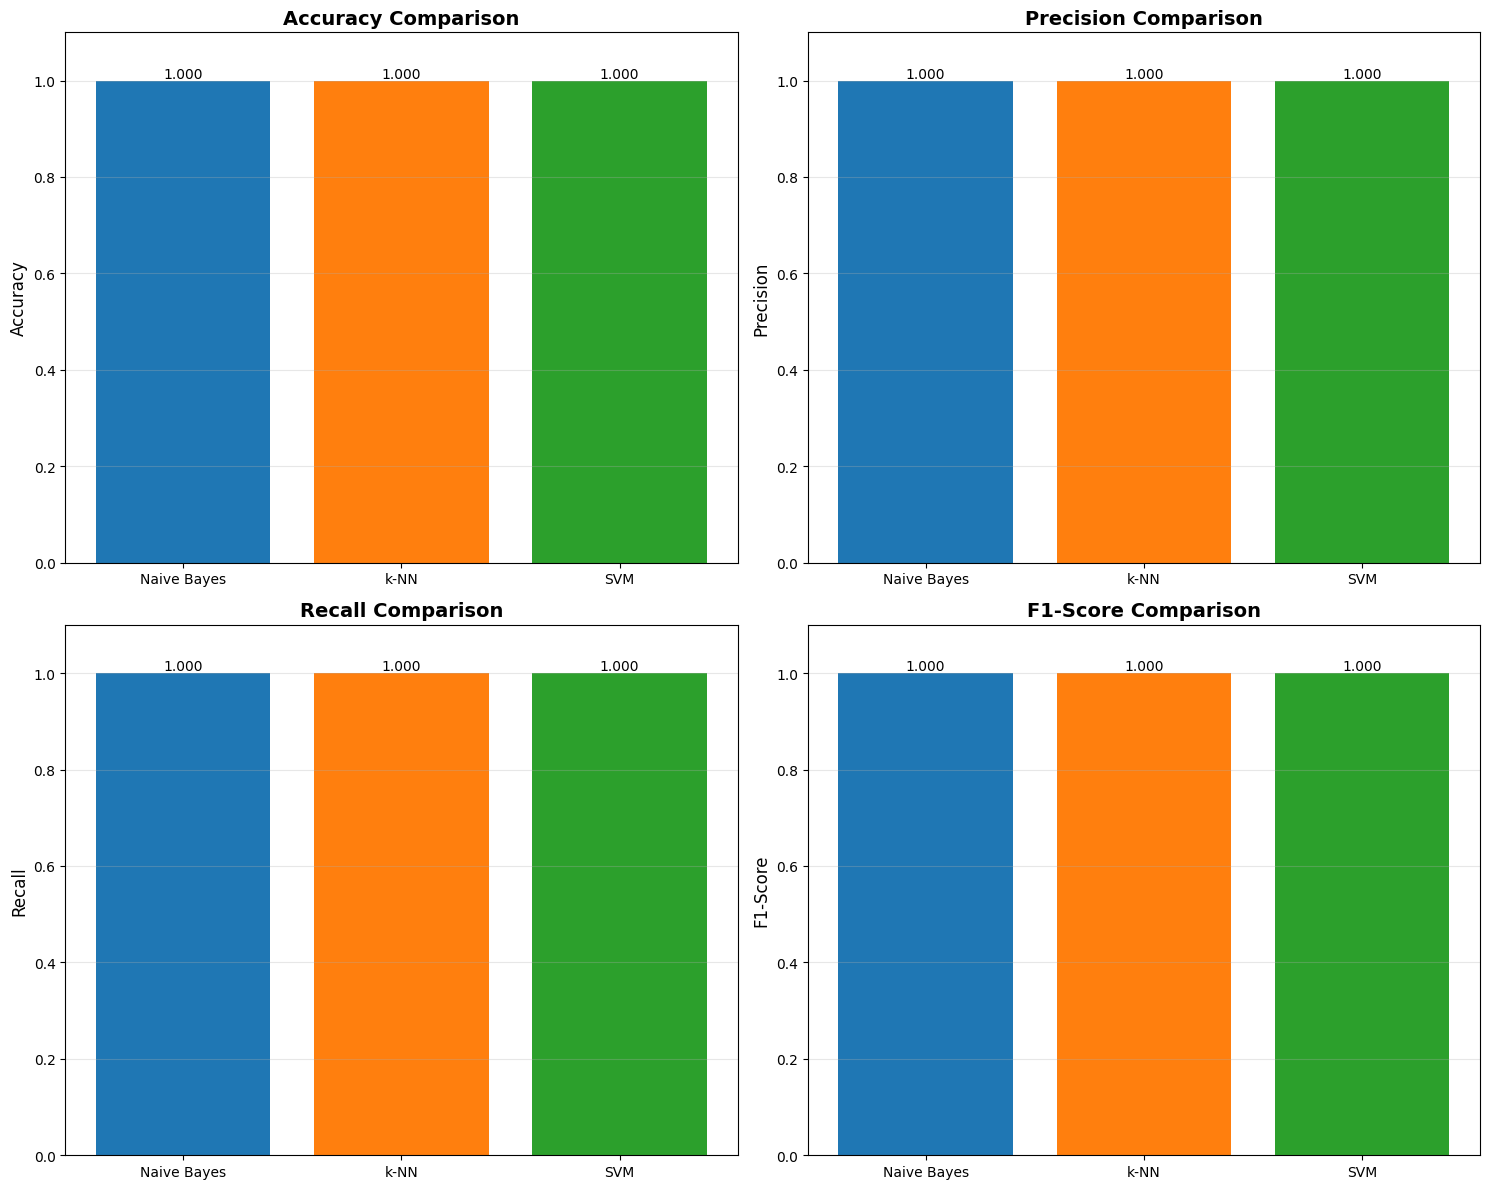

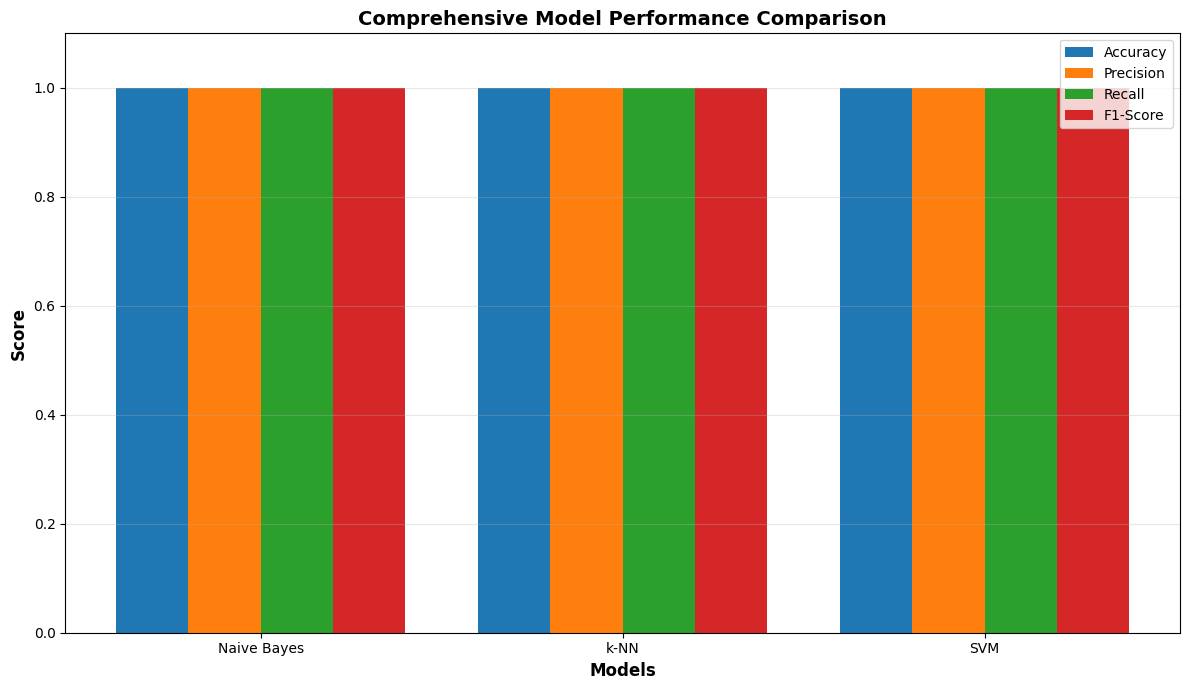

In [193]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', color='#1f77b4')
bars2 = ax.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision', color='#ff7f0e')
bars3 = ax.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall', color='#2ca02c')
bars4 = ax.bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', color='#d62728')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Discussion Questions

### Question 1: Which model performed better overall? Why do you think so?

All three models, Naive Bayes, k-NN, and SVM, achieved perfect performance, with 100% accuracy, precision, recall, and F1-score on the test set.
I did realize that if I get rid of the scaler, SVM goes down to a 73% accuracy, so I could say this is the "worse" one as it requires an extra step of scaling to make it have 100% accuracy.
Having all models have such high accuracy likely indicates that the 10 numerical features in the spam dataset provide very clear separation between the ham and spam classes, making it an easy classification problem that any reasonable algorithm can solve perfectly. In a scenario like this, Naive Bayes might be preferred simply because it is the fastest and simplest to train.

### Question 2: What is the difference between accuracy and precision? Which is more important for spam detection?

Accuracy measures the overall proportion of correct predictions out of all predictions made (both spam and ham).
Precision, on the other hand, measures specifically how many of the emails the model predicted as spam were actually spam.

For spam detection, precision is more important than accuracy. A false positive in spam detection means a legitimate (ham) email gets flagged as spam and potentially hidden from the user, which could cause them to miss important messages. High precision ensures that when the model labels something as spam, it is almost certainly spam. While high recall (catching all actual spam) is also valuable, incorrectly sending real emails to the spam folder is generally considered worse than letting a few spam emails through to the inbox.

### Question 3: When would you choose Naive Bayes over kNN or SVM in a real-world application?

Naive Bayes is a great choice when you need a fast, lightweight model that can be trained and updated quickly, especially on large datasets. Because it only needs to compute class probabilities and simple per-feature statistics, it trains in a single pass through the data and requires very little memory.

But, kNN stores the entire training set and must compute distances to all training points at prediction time, making it slow and memory-intensive for large datasets. SVM training can also be computationally expensive, particularly with non-linear kernels like RBF on large datasets.

### Question 4: What are the key assumptions of Naive Bayes? Do you think they hold true for this spam detection problem?

The key assumption of Naive Bayes is conditional independence: it assumes that all features are independent of each other given the class label.

In this spam detection problem, the independence assumption likely does not fully work. For example, features like `word_money` and `num_dollar` are probably correlated, an email that talks about money is also more likely to contain dollar signs. Also, `word_free` and `word_click` may tend to co-occur in promotional spam

### Question 5: How did you determine your value for $k$ in the kNN model?

The value of $k$ was determined by testing every integer value from 1 to 20 and evaluating each model's accuracy on the test set. A plot of accuracy versus `k` was generated to visualize performance across all candidate values. 
In this case, every value of `k` from 1 to 20 achieved 100% accuracy, so the algorithm selected `k = 1` as the best value. This is because the dataset's classes are perfectly separable with the given features.